### Libraries

In [10]:
import os
import numpy as np
import nibabel as nib
from nilearn import plotting
import matplotlib as plt
from brainspace.mesh.mesh_io import read_surface
from brainspace.datasets import load_mask
from brainspace.plotting import plot_hemispheres

### Load surfaces and masks

In [6]:
# Set the working directory to the 'out' directory
os.chdir("/data_/mica3/BIDS_MICs/derivatives") # <<<<<<<<<<<< CHANGE THIS PATH TO YOUR OUT DIRECTORY

# Path to MICAPIPE surf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

mask_lh =  nib.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_rh =  nib.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)
# Labels and boolean mask
mask_surf = mask_5k != 0

# Load fsLR 32k
f32k_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.surf.gii', itype='gii')
f32k_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.surf.gii', itype='gii')
# Load fsLR 32k inflated
f32k_inf_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.inflated.surf.gii', itype='gii')
f32k_inf_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.inflated.surf.gii', itype='gii')
mask_32k = load_mask(join=True)

# Load fsLR 5k
f5k_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.surf.gii', itype='gii')
f5k_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.surf.gii', itype='gii')

In [3]:
# This variable will be different for each subject
sub='Pilot14'           # <<<<<<<<<<<< CHANGE THIS SUBJECT's ID
ses='a1'              # <<<<<<<<<<<< CHANGE THIS SESSION
subjectID=f'sub-{sub}_ses-{ses}'
subjectDir=f'micapipe_v0.2.0/sub-{sub}/ses-{ses}'

# Here we define the atlas
atlas='schaefer-400'
# Set the path to the the MPC cortical connectome
mpc_acq='acq-T1map'

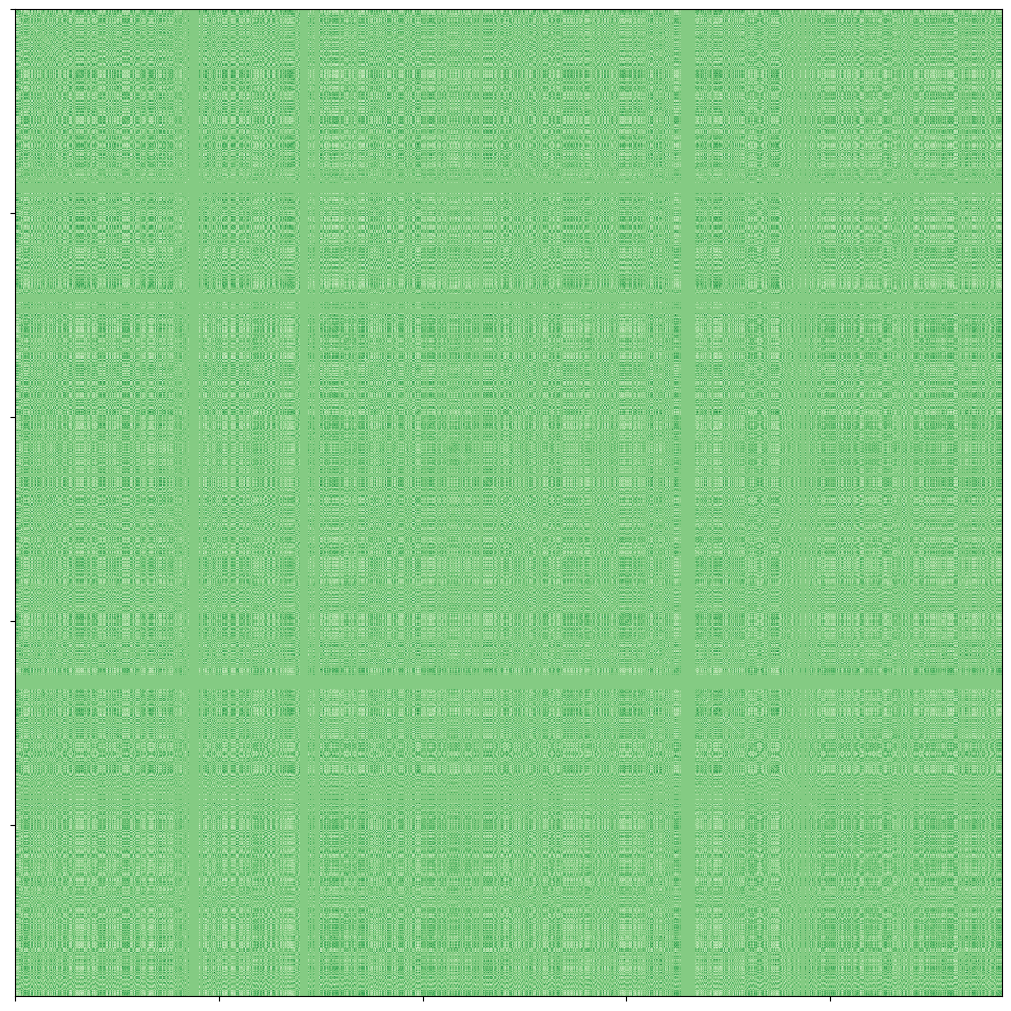

In [2]:
# Set the path to the Intensity profiles file
cnt_int = f'/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-Pilot014/ses-a1/mpc/acq-T1map/sub-Pilot014_ses-a1_surf-fsLR-5k_desc-MPC.shape.gii'

# Load the Intensity profiles
mtx_int = nib.load(cnt_int).darrays[0].data

# Plot as a matrix
corr_plot = plotting.plot_matrix(mtx_int, figure=(20,10), labels=None, cmap='Greens', colorbar=False)

In [23]:
# Create the gradients from the MPC matrix
def mpc_dm(MPC, mpc_mask, Ngrad=3, kernel=None, sparsity=0.9):
    # Cleanup before diffusion embeding
    MPC[~np.isfinite(MPC)] = 0
    MPC[np.isnan(MPC)] = 0
    MPC[MPC==0] = np.finfo(float).eps

    # Get the index of the non medial wall regions
    indx = np.where(mpc_mask==1)[0]

    # Slice the matrix
    MPC_masked = MPC[indx, :]
    MPC_masked = MPC_masked[:, indx]
    MPC_masked.shape

    # Calculate the gradients
    MPCgm = GradientMaps(n_components=Ngrad, random_state=None, approach='dm', kernel=kernel)
    MPCgm.fit(MPC_masked, sparsity=sparsity)
    
    # Map gradients to surface
    grad = [None] * Ngrad
    for i, g in enumerate(MPCgm.gradients_.T[0:Ngrad,:]):
        # create a new array filled with NaN values
        g_nan = np.full(mask_surf.shape, np.nan)
        g_nan[indx] = g

        # fill in the calculated values into the corresponding indices of the new array
        grad[i] = g_nan
    
    return (MPCgm, grad)

In [32]:
# Calculate the gradients
Ngrad=3
MPC_all, grad = mpc_dm(mtx_int, mask_surf, Ngrad=Ngrad, kernel=None, sparsity=0.95)

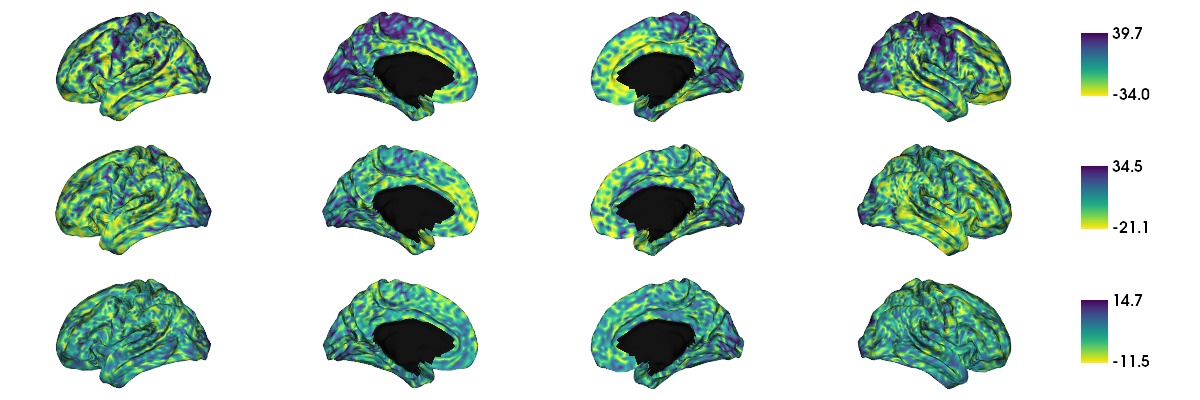

In [35]:
plot_hemispheres(f5k_lh, f5k_rh, array_name=grad, size=(1200, 400), cmap='viridis_r', embed_nb=True, color_bar=True, zoom=1.5)

In [30]:
test_lh =  nib.load('/host/percy/local_raid/youngeun/sub-AHEAD/sub-122017/test_lh.func.gii').darrays[0].data
test_rh =  nib.load('/host/percy/local_raid/youngeun/sub-AHEAD/sub-122017/test_rh.func.gii').darrays[0].data
test_mtx = np.concatenate((test_lh, test_rh), axis=0)

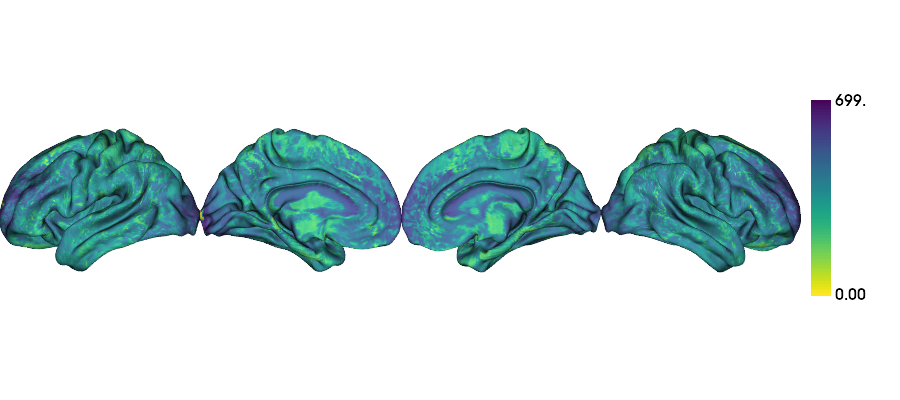

In [31]:
plot_hemispheres(f32k_lh, f32k_rh, array_name=test_mtx, size=(900, 400), cmap='viridis_r', embed_nb=True, color_bar=True, zoom=1.3)